# Automação com IA: sentimento das reviews

A análise exploratória (seção 8) mostrou que a nota do review não está vinculada à recompra. Isso levanta uma pergunta: a nota captura o sentimento real do cliente, ou o texto tem informação que a nota sozinha não mostra?

Esse notebook lê o texto das reviews com um modelo de IA pra resolver um problema real de operação: sinalizar os casos onde nota e texto divergem, sem precisar ler review por review.

## Abordagem técnica

Um modelo, open source e gratuito, rodando localmente, sem chave de API.

Classificador de sentimento (`nlptown/bert-base-multilingual-uncased-sentiment`), roda em todas as reviews com texto (~41 mil) e prevê uma nota de 1 a 5 a partir do texto. A diferença entre essa nota e a nota real mede a divergência.

## Setup

In [1]:
import time
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline

DB_PATH = "../data/processed/olist.duckdb"
CLASSIFICADOR_CACHE = Path("../data/processed/sentiment_scores.parquet")

conn = duckdb.connect(DB_PATH, read_only=True)

c:\Users\msuel\Documents\brazilian_ecommerce\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Passo 1: classificação em escala

Roda o classificador em todas as reviews com texto. O resultado fica em cache (a primeira vez leva ~25 min em CPU, depois é instantâneo). Pra reprocessar, basta apagar o arquivo de cache.

In [3]:
if CLASSIFICADOR_CACHE.exists():
    reviews = pd.read_parquet(CLASSIFICADOR_CACHE)
    print(f"Cache encontrado: {len(reviews)} reviews carregadas de {CLASSIFICADOR_CACHE}")
else:
    reviews = conn.sql('''
        SELECT
            review_id,
            order_id,
            review_score,
            review_comment_message
        FROM
            fct_reviews
        WHERE TRUE
            AND review_comment_message IS NOT NULL
            AND TRIM(review_comment_message) != ''
    ''').df()

    print(f"Classificando {len(reviews)} reviews (~25 min em CPU)...")
    classificador = pipeline(
        "sentiment-analysis",
        model="nlptown/bert-base-multilingual-uncased-sentiment",
        truncation=True,
        max_length=128,
    )

    textos = reviews["review_comment_message"].tolist()
    resultados = []
    t0 = time.time()
    for i in range(0, len(textos), 32):
        lote = textos[i:i + 32]
        resultados.extend(classificador(lote, batch_size=32))
        if (i // 32) % 50 == 0:
            print(f"{i + len(lote)}/{len(textos)} - {time.time() - t0:.0f}s")

    reviews["sentimento_previsto_estrelas"] = [int(r["label"][0]) for r in resultados]
    reviews["diff_sentimento"] = (reviews["sentimento_previsto_estrelas"] - reviews["review_score"]).abs()
    reviews["divergencia_forte"] = reviews["diff_sentimento"] >= 3

    reviews.to_parquet(CLASSIFICADOR_CACHE, index=False)
    print(f"Concluido em {(time.time() - t0)/60:.1f} min. Salvo em {CLASSIFICADOR_CACHE}")

reviews.head(3)

Cache encontrado: 40968 reviews carregadas de ..\data\processed\sentiment_scores.parquet


,review_id,order_id,review_score,review_comment_message,sentimento_previsto_estrelas,diff_sentimento,divergencia_forte
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,recebi bem antes do prazo estipulado.,3,2,False
1,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,parabéns lojas lannister adorei comprar pela i...,5,0,False
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,aparelho eficiente. no site a marca do aparelh...,3,1,False


## Validação do classificador

O objetivo não é acertar a nota exata, mas sim capturar a direção do sentimento. Por isso a validação usa 3 faixas (negativo, neutro, positivo) pra nota real e pra nota prevista, em vez de exigir acerto estrela a estrela.

In [4]:
def bucket(estrelas):
    if estrelas <= 2:
        return "negativo"
    if estrelas == 3:
        return "neutro"
    return "positivo"

reviews["bucket_real"] = reviews["review_score"].apply(bucket)
reviews["bucket_previsto"] = reviews["sentimento_previsto_estrelas"].apply(bucket)
reviews["concorda"] = reviews["bucket_real"] == reviews["bucket_previsto"]

taxa_concordancia = reviews["concorda"].mean() * 100
n_concorda = reviews["concorda"].sum()
print(f"Taxa de concordancia (mesma faixa): {taxa_concordancia:.1f}% ({n_concorda}/{len(reviews)})")

pd.crosstab(reviews["bucket_real"], reviews["bucket_previsto"], margins=True)

Taxa de concordancia (mesma faixa): 75.3% (30861/40968)


bucket_previsto,negativo,neutro,positivo,All
bucket_real,,,,
negativo,9756,561,573,10890
neutro,2002,763,792,3557
positivo,3787,2392,20342,26521
All,15545,3716,21707,40968


## Casos divergentes

Duas direções interessam pra triagem: nota alta com texto lido como negativo, e nota baixa com texto lido como positivo.

In [5]:
nota_alta_texto_negativo = reviews[(reviews["bucket_real"] == "positivo") & (reviews["bucket_previsto"] == "negativo")]
nota_baixa_texto_positivo = reviews[(reviews["bucket_real"] == "negativo") & (reviews["bucket_previsto"] == "positivo")]

print(f"Nota alta (4-5) mas texto lido como negativo: {len(nota_alta_texto_negativo)}")
print(f"Nota baixa (1-2) mas texto lido como positivo: {len(nota_baixa_texto_positivo)}")

Nota alta (4-5) mas texto lido como negativo: 3787
Nota baixa (1-2) mas texto lido como positivo: 573


## Passo 2: quantificar a divergência

A diferença entre a nota prevista e a nota real (`diff_sentimento`) já foi calculada no Passo 1 e está no cache. Aqui, olhamos a distribuição desses valores.

In [5]:
distribuicao_diff = reviews["diff_sentimento"].value_counts().sort_index()
distribuicao_diff_pct = (reviews["diff_sentimento"].value_counts(normalize=True).sort_index() * 100).round(1)

pd.DataFrame({"n_reviews": distribuicao_diff, "pct": distribuicao_diff_pct})

,n_reviews,pct
diff_sentimento,,
0,23830,58.2
1,9182,22.4
2,4134,10.1
3,1826,4.5
4,1996,4.9


`diff = 0` (58,2%) significa que o classificador acertou a nota exata. Além dos casos onde o classificador acertou, há muitos em que o erro fica entre 1 ou 2 estrelas, casos que não se tratam de discrepâncias grandes. O corte que importa é `diff >= 3`, quando nota e texto discordam por 3 ou 4 estrelas.

Divergência forte (diff >= 3): 3822 de 40968 (9.3%)

Por nota real:
review_score
1     416
2      88
4     888
5    2430
dtype: int64


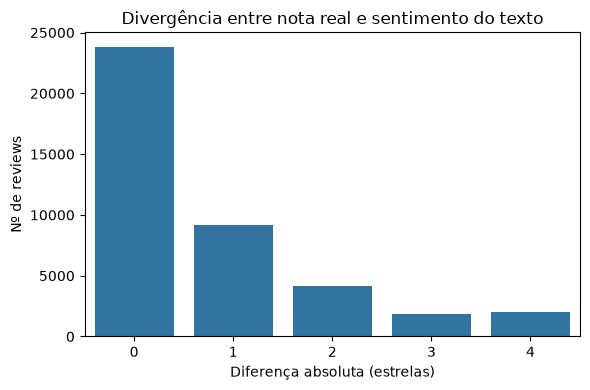

In [6]:
divergencia_forte = reviews[reviews["divergencia_forte"]]

print(f"Divergência forte (diff >= 3): {len(divergencia_forte)} de {len(reviews)} ({len(divergencia_forte)/len(reviews)*100:.1f}%)")
print("\nPor nota real:")
print(divergencia_forte.groupby("review_score").size())

plt.figure(figsize=(6, 4))
sns.barplot(x=distribuicao_diff.index, y=distribuicao_diff.values)
plt.title("Divergência entre nota real e sentimento do texto")
plt.xlabel("Diferença absoluta (estrelas)")
plt.ylabel("Nº de reviews")
plt.tight_layout()
plt.show()

Nota-se que 9,3% das reviews (3.822) apresentam incongruência entre a nota selecionada pelo cliente e o texto da avaliação. Esses casos são mais sensíveis, pois podem revelar problemas reais que ficaram escondidos por trás de uma nota positiva. O inverso também pode ocorrer: clientes satisfeitos que selecionaram uma nota ruim podem gerar gastos desnecessários com atendimento e impactar indevidamente as métricas de SLA.

## Tabela de Resultados Completa

Output completo da tabela de classificações de sentimento.


In [ ]:
sentiment_scores = pd.read_parquet(CLASSIFICADOR_CACHE)
sentiment_scores

,review_id,order_id,review_score,review_comment_message,sentimento_previsto_estrelas,diff_sentimento,divergencia_forte
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,recebi bem antes do prazo estipulado.,3,2,False
1,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,parabéns lojas lannister adorei comprar pela i...,5,0,False
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,aparelho eficiente. no site a marca do aparelh...,3,1,False
3,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,4,"mas um pouco ,travando...pelo valor ta boa.\r\n",3,1,False
4,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,5,"vendedor confiável, produto ok e entrega antes...",4,1,False
...,...,...,...,...,...,...,...
40963,98fffa80dc9acbde7388bef1600f3b15,d398e9c82363c12527f71801bf0e6100,4,para este produto recebi de acordo com a compr...,4,0,False
40964,df5fae90e85354241d5d64a8955b2b09,509b86c65fe4e2ad5b96408cfef9755e,5,entregou dentro do prazo. o produto chegou em ...,5,0,False
40965,a709d176f59bc3af77f4149c96bae357,d5cb12269711bd1eaf7eed8fd32a7c95,3,"o produto não foi enviado com nf, não existe v...",1,2,False
40966,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,"excelente mochila, entrega super rápida. super...",5,0,False


# Conclusão da Análise de Sentimento das Reviews

A análise demonstra que, embora a nota numérica reflita a experiência real do cliente na grande maioria dos casos, há uma parcela de casos onde o texto e a avaliação divergem de forma drástica. É exatamente nesse ponto que o modelo de inteligência artificial entra como uma solução prática e escalável.

## O que o modelo faz?
O classificador atua lendo automaticamente todos os comentários utilizando um modelo open source de processamento de linguagem natural. A partir desse texto, ele prevê qual seria a nota ideal (de 1 a 5 estrelas) do cliente baseando-se estritamente no sentimento da mensagem. Em seguida, o algoritmo cruza a nota prevista com a nota real atribuída na plataforma, calculando o nível de discrepância entre o que o cliente avaliou e o que o modelo previu. Por fim, o resultado é consolidado e armazenado em formato Parquet (data\processed\sentiment_scores.parquet), estruturando a tabela final de forma otimizada para garantir alta performance em consultas e integrações futuras.

## Por que essa automação é útil para a operação?
O modelo revisa os comentários atuando como um filtro inteligente de triagem, destacando os casos críticos de divergência (diferenças de 3 ou 4 estrelas), que representam 9,3% da base (3.822 reviews). Essa triagem automática traz dois grandes benefícios diretos:

*   **Encontra problemas camuflados:** Revela insatisfações reais, atritos na jornada ou defeitos de produto que ficaram escondidos por trás de uma nota positiva, permitindo atuação preventiva.
*   **Protege métricas e otimiza atendimento:** Identifica clientes que tiveram uma ótima experiência, mas selecionaram uma nota baixa (1 ou 2) por engano. Isso evita que a equipe de suporte perca tempo com acionamentos desnecessários e pode ser usado para impedir que esses erros afetem injustamente as métricas de qualidade e SLA da empresa.